In [110]:
import numpy as np

# poloha otocneho bodu
y = 140
x = 80

# rameno otocneho bodu
r = np.sqrt(x**2 + y**2)

# delka dvirek
d = 300

# chod motoru
s_min = 355
s_max = 610
s = s_max - s_min
print(f"Chod motoru: {s} mm")

# uchyceni motoru
xm = 35
ym = np.sqrt(s_max**2 - (x-xm)**2) - y
pm = np.array([xm, ym])

Chod motoru: 255 mm


In [111]:
# hruby vypocet uhlu otovreni
ar = np.arcsin(s/2 / r) * 2
ars = np.degrees(ar)

print(f"Uhel otevreni (zhruba): {ars:0.0f}°")

# nova poloha otocneho bodu
p = np.array([
    [x, -y], # otocny bod (tahlo)
    [0, -d], # konec dvirek
    [0, -y] # uchyceni tahla
])
R = np.array([
    [np.cos(ar), -np.sin(ar)],
    [np.sin(ar),  np.cos(ar)]
])
rp = p @ R.T
#xn = x * np.cos(-ar) - y * np.sin(-ar)
#yn = x * np.sin(-ar) + y * np.cos(-ar)
print(f"Otocny bod pri zavreno: {p[0]} mm")
print(f"Dvirka pri zavreno: {p[1]} mm")
print(f"Otocny bod otevreno: {rp[0]} mm")
print(f"Dvirka pri otevreno: {rp[1]} mm")
#print(rp)
distance = np.linalg.norm(pm - rp[0])
print(distance)

Uhel otevreni (zhruba): 105°
Otocny bod pri zavreno: [  80 -140] mm
Dvirka pri zavreno: [   0 -300] mm
Otocny bod otevreno: [115.49855898 112.5170337 ] mm
Dvirka pri otevreno: [290.43647254  75.14423077] mm
364.812974759652


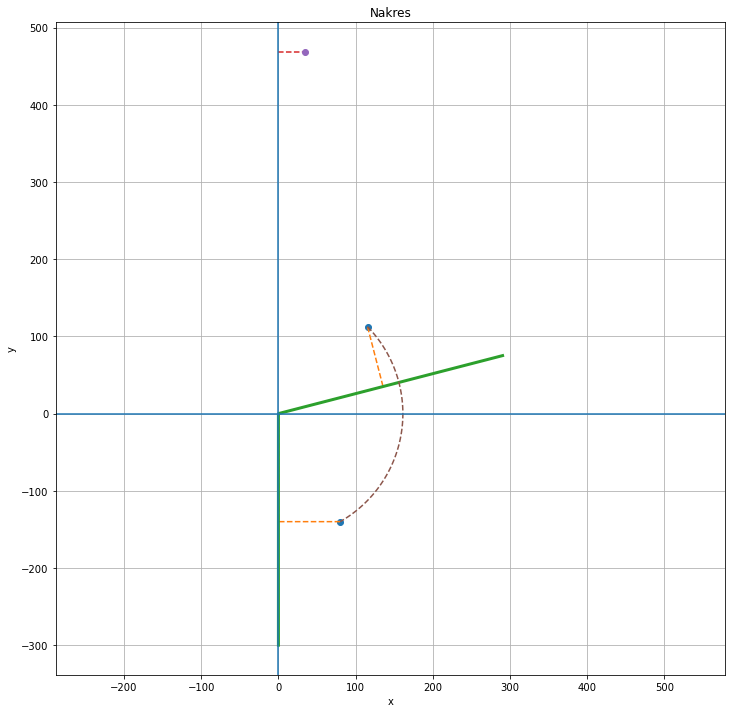

In [120]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))

ang = np.linspace(np.arctan(rp[0,1]/rp[0,0]), np.arctan(-y/x), 100)
xa = r * np.cos(ang)
ya = r * np.sin(ang)

# vykresleni usecky
plt.plot([p[0,0], rp[0,0]], [p[0,1], rp[0,1]], 'o')
plt.plot([p[0,0], p[2,0], 0, rp[2,0], rp[0,0]], [p[0,1], p[2,1], 0, rp[2,1], rp[0,1]], '--')
plt.plot([p[1,0], 0, rp[1,0]], [p[1,1], 0, rp[1,1]], linewidth=3)
plt.plot([0,xm], [ym,ym], '--')
plt.plot([xm], [ym], 'o')
plt.plot(xa, ya, '--')
plt.plot()

# pomocne osy
plt.axhline(0)
plt.axvline(0)

plt.axis('equal')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Nakres')

plt.show()